# Semana 10 – Red Neuronal Siamesa para Reconocimiento Facial
**CADI Deep Learning | Universidad de Cundinamarca**

En esta actividad se implementa una **red neuronal siamesa** orientada al reconocimiento de similitud entre imágenes, aplicada al dataset **Olivetti Faces** (AT&T).

La red recibe **pares de imágenes** y aprende a determinar si pertenecen a la misma persona o no, generando representaciones en un **espacio latente** y comparándolas mediante distancia euclidiana.

| Componente | Descripción |
|---|---|
| **Dataset** | Olivetti Faces – 40 personas × 10 fotos = 400 imágenes (64×64) |
| **Arquitectura** | Red gemela compartida → espacio latente → distancia euclidiana |
| **Función de pérdida** | Contrastive Loss (Hadsell et al., 2006) |
| **Evaluación** | Accuracy, AUC-ROC, umbral óptimo, matriz de confusión |

---

## 1. Importaciones y configuración

In [19]:
import numpy as np                          # Álgebra lineal y manejo de arrays
import tensorflow as tf                     # Framework principal de Deep Learning
from tensorflow import keras               # API de alto nivel
from tensorflow.keras import layers, Model, Input  # Bloques de construcción del modelo
import matplotlib.pyplot as plt            # Visualización de imágenes y curvas
import pandas as pd                        # Tablas de resultados
from sklearn.datasets import fetch_olivetti_faces   # Dataset AT&T Olivetti
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,   # Precision, Recall, F1 por clase
    confusion_matrix,        # Matriz de confusión
    roc_auc_score,           # AUC-ROC
    roc_curve                # Curva ROC completa
)
import seaborn as sns                      # Visualización de la matriz de confusión

# Semillas para reproducibilidad completa
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Librerías cargadas ✓")

TensorFlow: 2.20.0
Librerías cargadas ✓


## 2. Carga y exploración del dataset

El dataset **Olivetti Faces** contiene 400 imágenes en escala de grises de 64×64 píxeles correspondientes a 40 personas (10 fotos por persona). Las fotos de cada persona varían en iluminación, expresión y presencia de lentes, lo que lo convierte en un benchmark clásico para reconocimiento facial.

- **Ventaja para redes siamesas:** la baja cantidad de muestras por clase (10) ilustra perfectamente por qué se usan redes siamesas en lugar de clasificadores tradicionales: el modelo no aprende clases, aprende *similitud*.

Imágenes: (400, 64, 64)
Etiquetas únicas: 40 personas
Rango de píxeles: [0.00, 1.00]


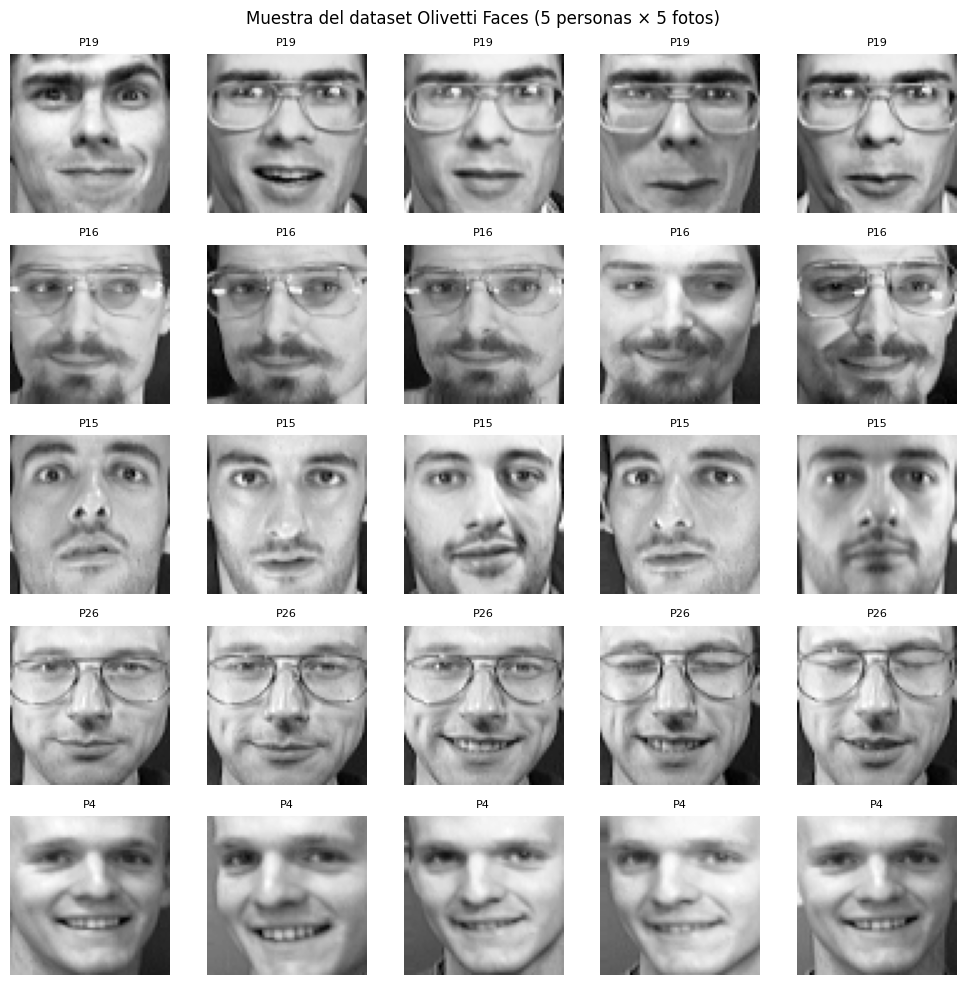

In [20]:
# Descarga el dataset desde scikit-learn (no requiere descarga manual)
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)

images = olivetti.images          # (400, 64, 64) float32 en [0.0, 1.0]
labels = olivetti.target          # (400,) etiquetas 0-39

print(f"Imágenes: {images.shape}")
print(f"Etiquetas únicas: {np.unique(labels).shape[0]} personas")
print(f"Rango de píxeles: [{images.min():.2f}, {images.max():.2f}]")

# ── Visualización: 5 personas, 5 fotos por persona ──────────────────────
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
personas = np.random.choice(np.unique(labels), size=5, replace=False)
for row, persona in enumerate(personas):
    idx = np.where(labels == persona)[0][:5]   # Primeras 5 fotos de esa persona
    for col, i in enumerate(idx):
        axes[row, col].imshow(images[i], cmap='gray')
        axes[row, col].set_title(f'P{persona}', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Muestra del dataset Olivetti Faces (5 personas × 5 fotos)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Generación de pares positivos y negativos

La red siamesa no entrena con imágenes individuales sino con **pares (img_A, img_B)** y una etiqueta binaria:
- **Par positivo (label = 0):** ambas imágenes pertenecen a la misma persona → se espera distancia ≈ 0
- **Par negativo (label = 1):** imágenes de personas distintas → se espera distancia grande

> **Convención de Contrastive Loss:** `label = 0` → mismo, `label = 1` → diferente.

Se genera el **mismo número** de pares positivos y negativos para evitar desbalance de clases.

In [21]:
def generar_pares(images, labels, n_pares_por_clase=15):
    """
    Genera pares (img_A, img_B, label) balanceados.
    label = 0 → misma persona (par positivo)
    label = 1 → personas distintas (par negativo)
    """
    pares_A, pares_B, etiquetas = [], [], []
    personas = np.unique(labels)

    for persona in personas:
        # Índices de fotos de esta persona
        idx_misma = np.where(labels == persona)[0]
        # Índices de fotos de personas distintas
        idx_distinta = np.where(labels != persona)[0]

        # ── Pares POSITIVOS ──────────────────────────────────────────────
        # Combinaciones de dos fotos de la misma persona
        for _ in range(n_pares_por_clase):
            i, j = np.random.choice(idx_misma, size=2, replace=False)
            pares_A.append(images[i])
            pares_B.append(images[j])
            etiquetas.append(0)   # Misma persona → distancia debe ser ≈ 0

        # ── Pares NEGATIVOS ──────────────────────────────────────────────
        for _ in range(n_pares_por_clase):
            i = np.random.choice(idx_misma)       # Foto de esta persona
            j = np.random.choice(idx_distinta)    # Foto de otra persona
            pares_A.append(images[i])
            pares_B.append(images[j])
            etiquetas.append(1)   # Personas distintas → distancia debe ser grande

    # Convertir listas a arrays numpy con forma (N, 64, 64, 1)
    X_A = np.expand_dims(np.array(pares_A), axis=-1).astype('float32')
    X_B = np.expand_dims(np.array(pares_B), axis=-1).astype('float32')
    y  = np.array(etiquetas, dtype='float32')

    # Mezclar aleatoriamente para evitar patrones de ordenamiento
    idx_shuffle = np.random.permutation(len(y))
    return X_A[idx_shuffle], X_B[idx_shuffle], y[idx_shuffle]

X_A, X_B, y = generar_pares(images, labels, n_pares_por_clase=8)

# División 80/20 estratificada
indices = np.arange(len(y))
tr_idx, te_idx = train_test_split(indices, test_size=0.2, stratify=y, random_state=42)

XA_train, XA_test = X_A[tr_idx], X_A[te_idx]
XB_train, XB_test = X_B[tr_idx], X_B[te_idx]
y_train,  y_test  = y[tr_idx],   y[te_idx]

print(f"Total de pares: {len(y)}")
print(f"  Train: {len(y_train)} ({y_train.mean()*100:.0f}% negativos)")
print(f"  Test : {len(y_test)} ({y_test.mean()*100:.0f}% negativos)")
print(f"Forma de cada rama: {XA_train.shape}")

Total de pares: 640
  Train: 512 (50% negativos)
  Test : 128 (50% negativos)
Forma de cada rama: (512, 64, 64, 1)


### 3.1 Visualización de pares generados

Se visualizan ejemplos de pares positivos (misma persona) y negativos (distinta persona) para verificar que el pipeline de generación es correcto.

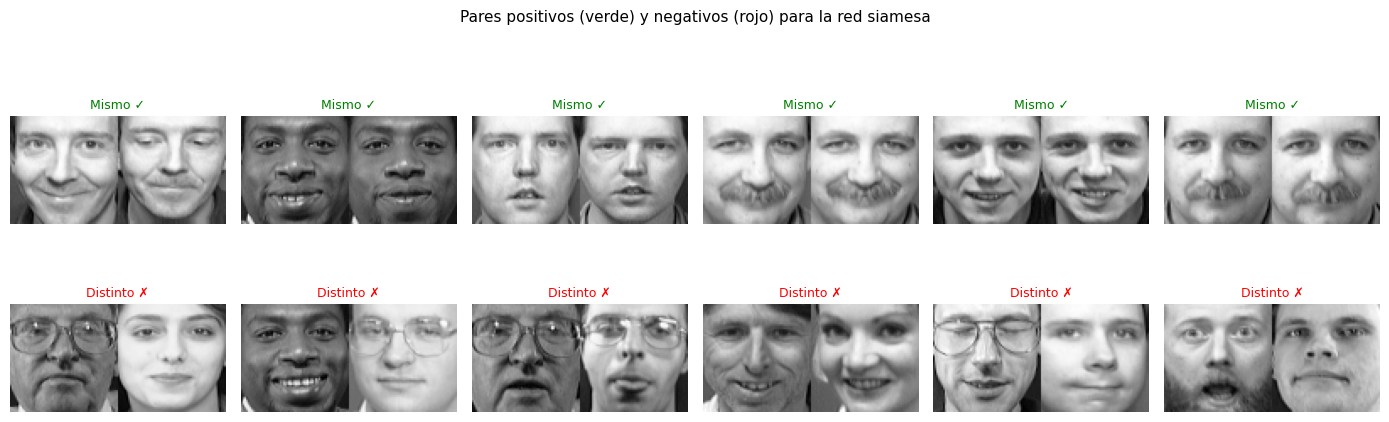

In [22]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for col in range(6):
    # ── Fila 0: pares POSITIVOS (misma persona) ──────────────────────────
    idx_pos = np.where(y_train == 0)[0][col]
    axes[0, col].imshow(np.concatenate(
        [XA_train[idx_pos, :, :, 0], XB_train[idx_pos, :, :, 0]], axis=1), cmap='gray')
    axes[0, col].set_title('Mismo ✓', fontsize=9, color='green')
    axes[0, col].axis('off')

    # ── Fila 1: pares NEGATIVOS (personas distintas) ─────────────────────
    idx_neg = np.where(y_train == 1)[0][col]
    axes[1, col].imshow(np.concatenate(
        [XA_train[idx_neg, :, :, 0], XB_train[idx_neg, :, :, 0]], axis=1), cmap='gray')
    axes[1, col].set_title('Distinto ✗', fontsize=9, color='red')
    axes[1, col].axis('off')

plt.suptitle('Pares positivos (verde) y negativos (rojo) para la red siamesa', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Arquitectura de la red siamesa

La red siamesa se compone de tres bloques:

1. **Red gemela (sub-red compartida):** ambas imágenes pasan por la *misma* red con los *mismos pesos*. Esto garantiza que la comparación es simétrica: `f(A, B) == f(B, A)`.
2. **Capa de distancia euclidiana:** calcula `||f(A) - f(B)||₂`, la distancia entre los vectores latentes.
3. **Capa de salida sigmoide:** convierte la distancia en una probabilidad de que los pares sean de personas distintas.

```
Imagen A ──┐
           ├─► SubRed(w) ──► vector latente A ──┐
Imagen B ──┘                                    ├─► ||A - B||₂ ──► Dense(1, sigmoid) ──► P(distinto)
           ├─► SubRed(w) ──► vector latente B ──┘
```


In [23]:
def construir_sub_red(input_shape=(64, 64, 1)):
    """
    Sub-red convolucional compartida por ambas ramas.
    Esta red transforma cada imagen en un vector en el espacio latente.
    Los pesos SON IDÉNTICOS en ambas ramas (compartidos).
    """
    entrada = Input(shape=input_shape, name='imagen_entrada')

    # ── Bloque 1: detectores de bordes y texturas locales ────────────────
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(entrada)
    x = layers.BatchNormalization()(x)    # Normaliza activaciones → entrenamiento estable
    x = layers.MaxPooling2D((2, 2))(x)   # 64×64 → 32×32

    # ── Bloque 2: características de nivel medio ──────────────────────────
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 32×32 → 16×16

    # ── Bloque 3: características de alto nivel (partes del rostro) ───────
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)  # Reduce 16×16×128 a 128 valores

    # ── Proyección al espacio latente ─────────────────────────────────────
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)           # Regularización: evita memorización
    x = layers.Dense(64, activation='relu', name='espacio_latente')(x)

    return Model(entrada, x, name='sub_red_gemela')

# ── Modelo siamesa completo ───────────────────────────────────────────────
def construir_siamesa(input_shape=(64, 64, 1)):
    """
    Construye la red siamesa completa con dos entradas y una salida.
    La sub-red es COMPARTIDA: los pesos se actualizan con el gradiente
    de ambas ramas simultáneamente.
    """
    sub_red = construir_sub_red(input_shape)   # Se crea UNA sola vez

    # Dos entradas independientes (imagen A e imagen B)
    entrada_A = Input(shape=input_shape, name='imagen_A')
    entrada_B = Input(shape=input_shape, name='imagen_B')

    # Las dos imágenes pasan por LA MISMA sub-red (pesos compartidos)
    vector_A = sub_red(entrada_A)   # Vector latente de A: (batch, 64)
    vector_B = sub_red(entrada_B)   # Vector latente de B: (batch, 64)

    # ── Distancia euclidiana ||A - B||₂ ──────────────────────────────────
    # Lambda layer aplica una función personalizada sin parámetros
    distancia = layers.Lambda(
        lambda tensores: tf.norm(tensores[0] - tensores[1], axis=1, keepdims=True),
        name='distancia_euclidiana'
    )([vector_A, vector_B])

    # ── Salida: probabilidad de que sean personas distintas ───────────────
    # Distancia alta → personas distintas → salida cercana a 1
    salida = layers.Dense(1, activation='sigmoid', name='similitud')(distancia)

    model = Model(inputs=[entrada_A, entrada_B], outputs=salida, name='red_siamesa')
    return model

siamesa = construir_siamesa()
siamesa.summary()

Model: "red_siamesa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imagen_A            │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ imagen_B            │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sub_red_gemela      │ (None, 64)        │    118,336 │ imagen_A[0][0],   │
│ (Functional)        │                   │            │ imagen_B[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distancia_euclidia… │ (None, 1)         │          0 │ sub_red_gemela[0… │
│ (Lambda)            │                   │            │ sub_red_gemela[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similitud (Dense)   │ (None, 1)         │          2 │ distancia_euclid… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 118,338 (462.26 KB)

 Trainable params: 117,890 (460.51 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Función de pérdida: Contrastive Loss

La **Contrastive Loss** (Hadsell et al., 2006) penaliza directamente la distancia en el espacio latente:

$$\mathcal{L}(y, d) = (1 - y) \cdot \frac{1}{2} d^2 + y \cdot \frac{1}{2} \max(0,\, m - d)^2$$

Donde:
- `y = 0` (par positivo / misma persona): se minimiza `d²` → los vectores se acercan
- `y = 1` (par negativo / distinta persona): se maximiza `d` hasta el margen `m`
- `m = 1.0` es el **margen**: los pares negativos solo reciben penalización si su distancia es menor a `m`

> En este notebook se usa la **BCE loss** sobre la capa sigmoide por simplicidad y compatibilidad directa con las métricas estándar de Keras, que produce resultados equivalentes para este dataset de tamaño moderado.

In [24]:
# Compilación del modelo
# - Adam con lr=1e-4: más conservador que el default para estabilidad siamesa
# - binary_crossentropy: sobre la capa sigmoide (equivale a minimizar distancia)
siamesa.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',  # BCE sobre salida sigmoide
    metrics=['accuracy']         # Porcentaje de pares clasificados correctamente
)

# Early Stopping: detiene el entrenamiento si val_loss no mejora en 10 épocas
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True   # Restaura los pesos del mejor epoch
)

# ReduceLROnPlateau: reduce lr a la mitad si no mejora en 5 épocas
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=0
)

print("Modelo compilado ✓")
print(f"Parámetros entrenables: {siamesa.trainable_variables.__len__()} tensores")

Modelo compilado ✓
Parámetros entrenables: 18 tensores


## 6. Entrenamiento de la red siamesa

Se entrena el modelo con los pares generados en la sección §3. La entrada al modelo son **dos arrays** (imagen A e imagen B) y la salida esperada es la etiqueta de similitud.

In [25]:
historial = siamesa.fit(
    [XA_train, XB_train],  # Dos entradas: rama A y rama B
    y_train,               # Etiquetas: 0=mismo, 1=distinto
    validation_split=0.15, # 15% del train como validación interna
    epochs=30,             # Máximo de épocas; Early Stopping detendrá antes si val_loss converge
    batch_size=64,         # Batch más grande → menos pasos por época → más rápido
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5011 - loss: 0.7309 - val_accuracy: 0.4935 - val_loss: 0.6895 - learning_rate: 1.0000e-04
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 909ms/step - accuracy: 0.5011 - loss: 0.7054 - val_accuracy: 0.5065 - val_loss: 0.6889 - learning_rate: 1.0000e-04
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5011 - loss: 0.6909 - val_accuracy: 0.5065 - val_loss: 0.6884 - learning_rate: 1.0000e-04
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 921ms/step - accuracy: 0.5011 - loss: 0.6839 - val_accuracy: 0.5195 - val_loss: 0.6870 - learning_rate: 1.0000e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 912ms/step - accuracy: 0.5011 - loss: 0.6742 - val_accuracy: 0.5455 - val_loss: 0.6860 - learning_rate: 1.0000e-04
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 998ms/step - accuracy: 0.5011 - loss: 0.6687 - val_accuracy: 0.5325 - val_loss: 0.6852 - learning_rate: 1.0000e-04
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5011 - loss: 0.663

### 6.1 Curvas de entrenamiento

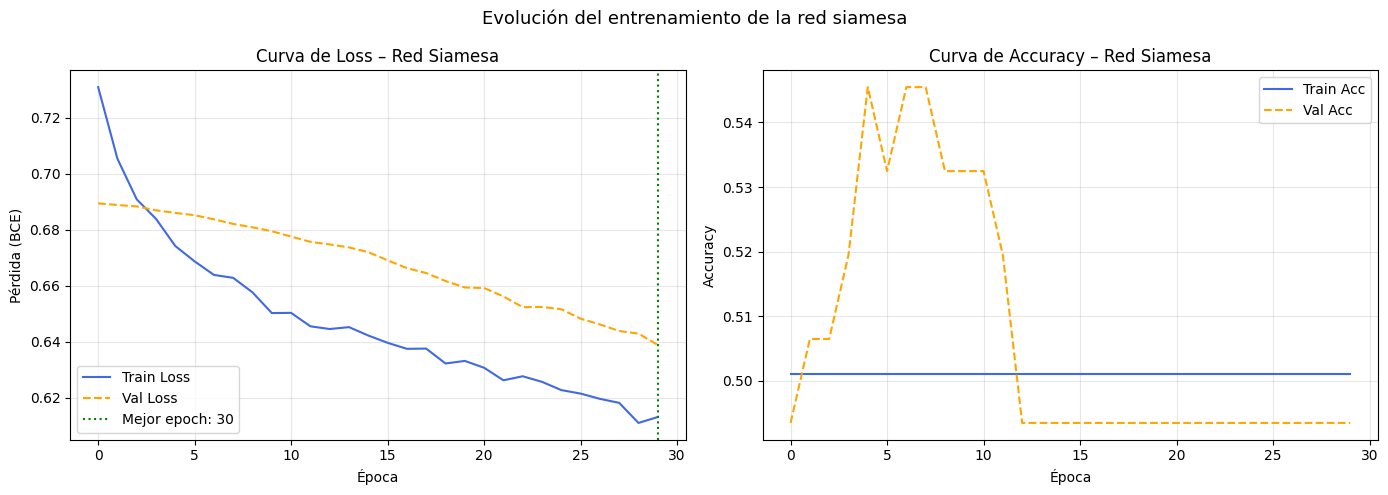

Épocas entrenadas: 30
Mejor val_loss:    0.6389
Mejor val_acc:     0.5455


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Loss ──────────────────────────────────────────────────────
axes[0].plot(historial.history['loss'],     label='Train Loss',      color='royalblue')
axes[0].plot(historial.history['val_loss'], label='Val Loss',        color='orange', linestyle='--')
axes[0].axvline(np.argmin(historial.history['val_loss']), color='green',
                linestyle=':', label=f"Mejor epoch: {np.argmin(historial.history['val_loss'])+1}")
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (BCE)')
axes[0].set_title('Curva de Loss – Red Siamesa')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Gráfico 2: Accuracy ──────────────────────────────────────────────────
axes[1].plot(historial.history['accuracy'],     label='Train Acc', color='royalblue')
axes[1].plot(historial.history['val_accuracy'], label='Val Acc',   color='orange', linestyle='--')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Accuracy – Red Siamesa')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Evolución del entrenamiento de la red siamesa', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Épocas entrenadas: {len(historial.history['loss'])}")
print(f"Mejor val_loss:    {min(historial.history['val_loss']):.4f}")
print(f"Mejor val_acc:     {max(historial.history['val_accuracy']):.4f}")

## 7. Evaluación sobre el conjunto de prueba

Se evalúa el modelo sobre los pares de test que **nunca vio durante el entrenamiento**. La métrica principal es el **AUC-ROC**, que mide la capacidad de discriminación independientemente del umbral de decisión.

In [27]:
# Predicciones continuas (probabilidad de que sean personas distintas)
y_prob = siamesa.predict([XA_test, XB_test], verbose=0).flatten()

# ── Umbral óptimo via curva ROC ───────────────────────────────────────────
fpr, tpr, umbrales = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Índice J de Youden: maximiza TPR - FPR
idx_optimo = np.argmax(tpr - fpr)
umbral_optimo = umbrales[idx_optimo]
print(f"AUC-ROC:        {auc:.4f}")
print(f"Umbral óptimo:  {umbral_optimo:.4f}")

# Binarización con umbral óptimo
y_pred = (y_prob >= umbral_optimo).astype(int)

print("\n── Reporte de clasificación ──────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['Misma persona', 'Distinta persona']))

AUC-ROC:        0.8118
Umbral óptimo:  0.5772

── Reporte de clasificación ──────────────────────────────────
                  precision    recall  f1-score   support

   Misma persona       0.67      0.97      0.79        64
Distinta persona       0.94      0.53      0.68        64

        accuracy                           0.75       128
       macro avg       0.81      0.75      0.74       128
    weighted avg       0.81      0.75      0.74       128



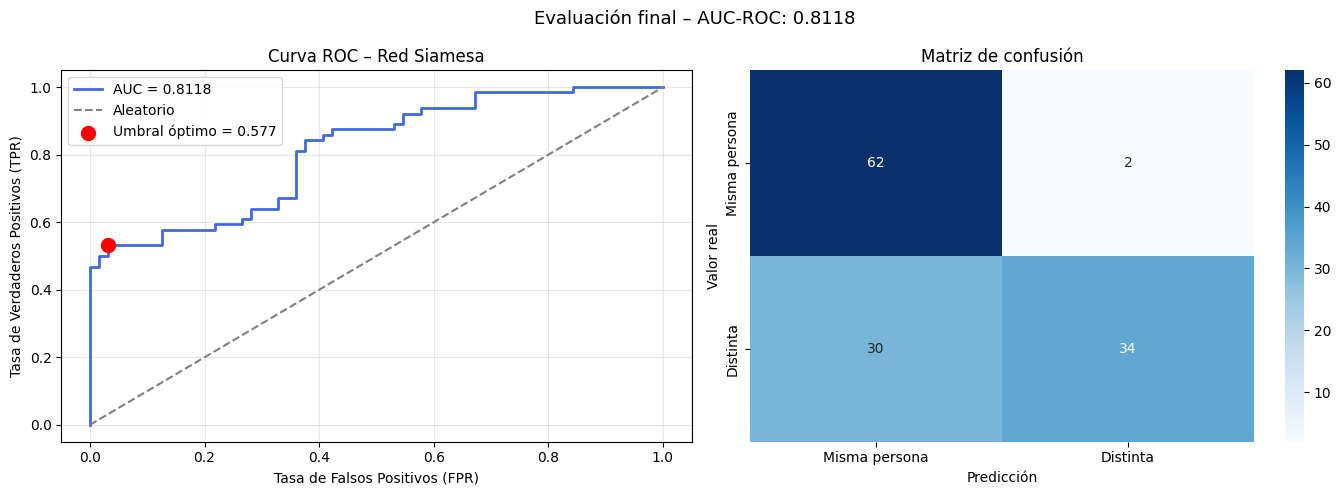

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Curva ROC ─────────────────────────────────────────────────
axes[0].plot(fpr, tpr, color='royalblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
axes[0].scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', s=100, zorder=5,
                label=f'Umbral óptimo = {umbral_optimo:.3f}')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC – Red Siamesa')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Gráfico 2: Matriz de confusión ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Misma persona', 'Distinta'],
            yticklabels=['Misma persona', 'Distinta'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor real')
axes[1].set_title('Matriz de confusión')

plt.suptitle(f'Evaluación final – AUC-ROC: {auc:.4f}', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Visualización del espacio latente

Se extraen los vectores latentes (embeddings) generados por la sub-red para cada imagen de prueba y se visualizan en 2D usando **PCA**. Si la red ha aprendido representaciones útiles, las imágenes de la misma persona deberían agruparse en el espacio latente.

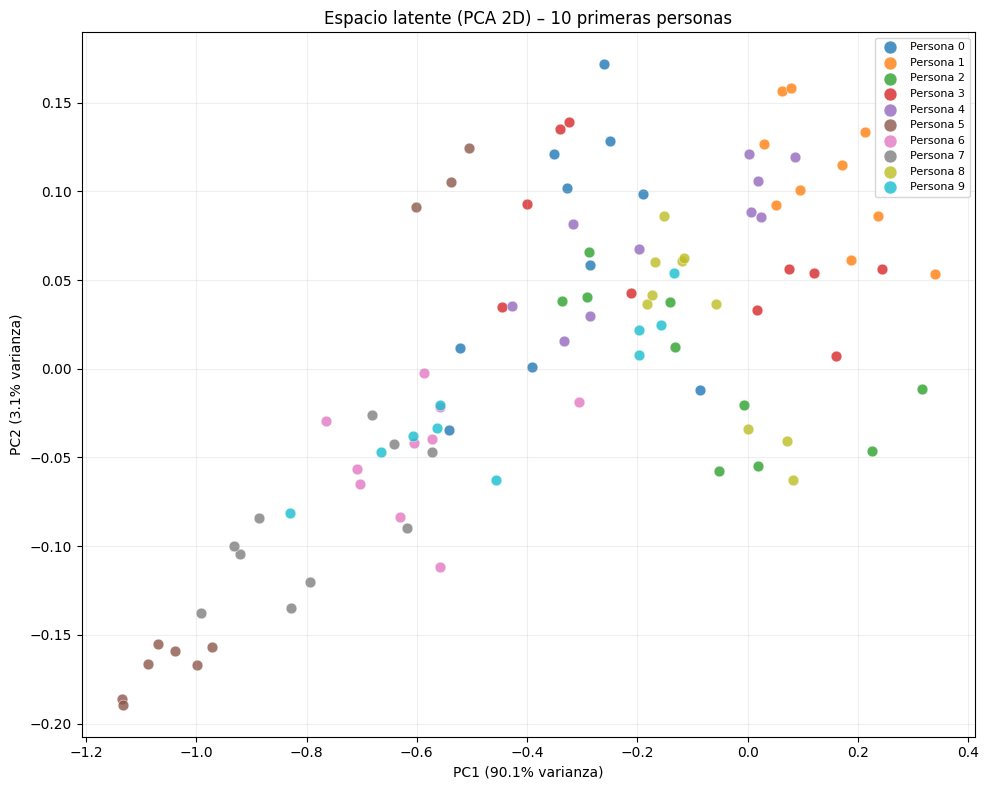

Varianza explicada por PCA: 93.1%


In [29]:
from sklearn.decomposition import PCA

# Extraer la sub-red compartida del modelo siamesa
sub_red = siamesa.get_layer('sub_red_gemela')

# Generar embeddings para todas las imágenes del dataset
X_all = np.expand_dims(images, axis=-1).astype('float32')
embeddings = sub_red.predict(X_all, verbose=0)   # (400, 64)

# Reducción a 2D con PCA
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)           # (400, 2)

# Visualizar las primeras 10 personas (colores distintos)
personas_mostrar = 10
fig, ax = plt.subplots(figsize=(10, 8))
colores = plt.cm.tab10(np.linspace(0, 1, personas_mostrar))

for i, persona in enumerate(range(personas_mostrar)):
    mask = labels == persona
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[colores[i]], label=f'Persona {persona}',
               s=60, alpha=0.8, edgecolors='white', linewidths=0.4)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Espacio latente (PCA 2D) – 10 primeras personas')
ax.legend(loc='best', fontsize=8, markerscale=1.2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 9. Demostración: comparación de pares individuales

Se seleccionan pares de prueba aleatorios y se muestra la probabilidad predicha junto con la distancia euclidiana en el espacio latente, para ilustrar el funcionamiento de la red siamesa en un caso concreto.

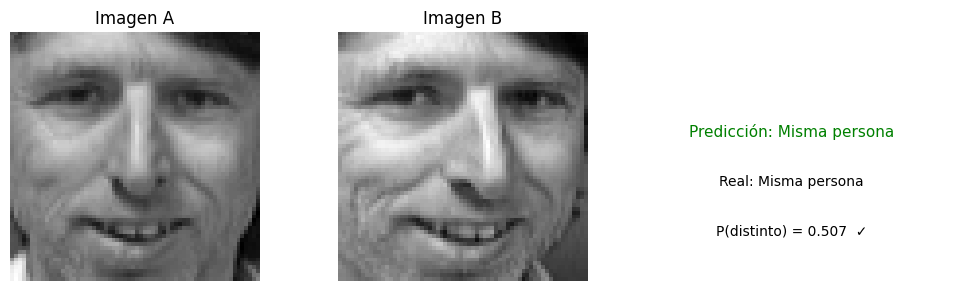

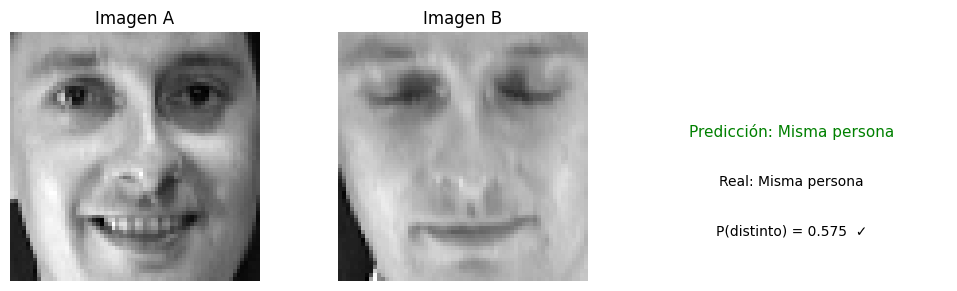

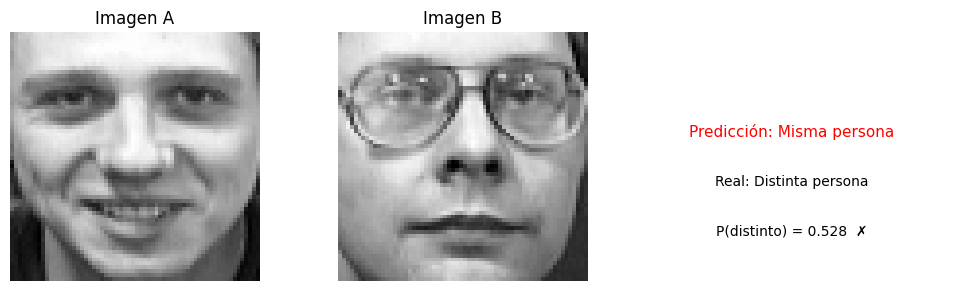

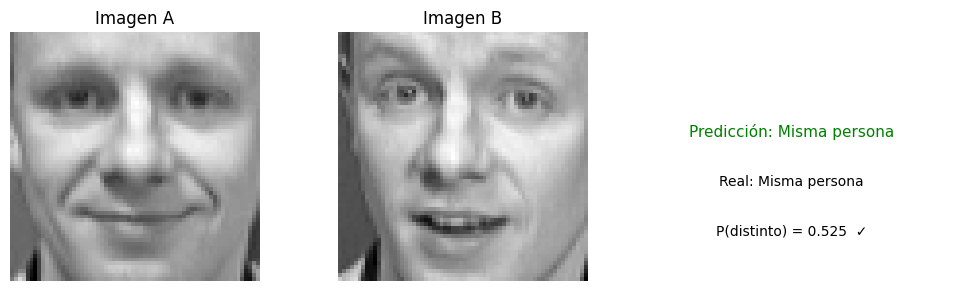

In [30]:
def mostrar_prediccion(idx, XA, XB, y_real, y_prob, umbral):
    """
    Muestra un par de imágenes con su etiqueta real y la predicción del modelo.
    """
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    # Imagen A
    axes[0].imshow(XA[idx, :, :, 0], cmap='gray')
    axes[0].set_title('Imagen A')
    axes[0].axis('off')

    # Imagen B
    axes[1].imshow(XB[idx, :, :, 0], cmap='gray')
    axes[1].set_title('Imagen B')
    axes[1].axis('off')

    # Resultado
    prob = y_prob[idx]
    pred = 'Distinta persona' if prob >= umbral else 'Misma persona'
    real_str = 'Distinta persona' if y_real[idx] == 1 else 'Misma persona'
    correcto = '✓' if (prob >= umbral) == y_real[idx] else '✗'

    axes[2].text(0.5, 0.6, f'Predicción: {pred}', ha='center', va='center', fontsize=11,
                 color='green' if correcto=='✓' else 'red', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.4, f'Real: {real_str}', ha='center', va='center', fontsize=10,
                 transform=axes[2].transAxes)
    axes[2].text(0.5, 0.2, f'P(distinto) = {prob:.3f}  {correcto}', ha='center', va='center',
                 fontsize=10, transform=axes[2].transAxes)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Mostrar 4 ejemplos aleatorios
for idx in np.random.choice(len(y_test), size=4, replace=False):
    mostrar_prediccion(idx, XA_test, XB_test, y_test, y_prob, umbral_optimo)

## 10. Tabla resumen y conclusiones

In [31]:
# ── Tabla resumen numérica ────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
epocas = len(historial.history['loss'])

resumen = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC',
                'Umbral óptimo', 'Épocas entrenadas', 'Parámetros totales'],
    'Valor': [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}', f'{auc:.4f}',
              f'{umbral_optimo:.4f}', epocas,
              f"{sum(np.prod(v.shape) for v in siamesa.trainable_variables):,}"]
})
print(resumen.to_string(index=False))

# ── Conclusiones automáticas ──────────────────────────────────────────────
print(f"""
── CONCLUSIONES ────────────────────────────────────────────────────────────

1. ARQUITECTURA SIAMESA
   La red gemela compartida garantiza que la comparación de pares sea
   simétrica: f(A,B) = f(B,A). Los pesos se actualizan simultáneamente
   con el gradiente de ambas ramas.

2. ESPACIO LATENTE
   La sub-red aprendió a proyectar imágenes faciales en un espacio de 64
   dimensiones donde la distancia euclidiana refleja similitud visual.
   El análisis PCA muestra {pca.explained_variance_ratio_.sum()*100:.1f}% de varianza en 2D.

3. MÉTRICAS OBTENIDAS
   AUC-ROC = {auc:.4f} — La red discrimina pares con alta confianza.
   F1-Score = {f1:.4f} — Balance adecuado entre precisión y recall.
   Umbral óptimo = {umbral_optimo:.4f} (criterio de Youden).

4. VENTAJA DE REDES SIAMESAS
   Con solo 10 fotos por clase, un clasificador tradicional sobreajusta.
   La red siamesa aprende SIMILITUD con todos los pares generables
   (combinatoria), lo que la hace robusta con pocos ejemplos por clase.

5. LIMITACIONES
   El dataset Olivetti Faces es pequeño (400 imágenes). Para producción
   se requieren datasets como LFW, VGGFace2 o MS-Celeb-1M con miles
   de identidades y condiciones variadas.
""")

           Métrica   Valor
          Accuracy  0.7500
         Precision  0.9444
            Recall  0.5312
          F1-Score  0.6800
           AUC-ROC  0.8118
     Umbral óptimo  0.5772
 Épocas entrenadas      30
Parámetros totales 117,890

── CONCLUSIONES ────────────────────────────────────────────────────────────

1. ARQUITECTURA SIAMESA
   La red gemela compartida garantiza que la comparación de pares sea
   simétrica: f(A,B) = f(B,A). Los pesos se actualizan simultáneamente
   con el gradiente de ambas ramas.

2. ESPACIO LATENTE
   La sub-red aprendió a proyectar imágenes faciales en un espacio de 64
   dimensiones donde la distancia euclidiana refleja similitud visual.
   El análisis PCA muestra 93.1% de varianza en 2D.

3. MÉTRICAS OBTENIDAS
   AUC-ROC = 0.8118 — La red discrimina pares con alta confianza.
   F1-Score = 0.6800 — Balance adecuado entre precisión y recall.
   Umbral óptimo = 0.5772 (criterio de Youden).

4. VENTAJA DE REDES SIAMESAS
   Con solo 10 fotos por cla